# FlexPose 虚拟筛选教程

对应书稿章节：3.2.3 柔性对接（蛋白 / 配体联合坐标修正）。
教学数据：使用 `demo_data/CoreSet.dat` 中的 20 个代表性复合物子集，不等同于完整 CASF-2016 core set。

本 notebook 只保留 **蛋白 / 配体联合坐标修正** 这条技术路线。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `RMSD < 2A`

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.spatial import distance_matrix
from rdkit import RDLogger
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, atom_features, build_mlp, compute_rmsd,
    describe_model_parameters, history_frame, load_complex,
    metric_frame, parse_coreset, plot_loss_curves,
)

## 1. 超参数设置

| 参数 | 含义 | 说明 |
|------|------|------|
| `DISTANCE_CUTOFF` | 交互边距离阈值 | 蛋白-配体原子对距离 < 该值时建边 |
| `HIDDEN_DIM` | 隐层维度 | 节点嵌入和 MLP 的隐藏层维度 |
| `COOR_SCALE` | 坐标归一化因子 | 对齐原始仓库，训练时坐标除以 10 保证数值稳定 |
| `N_CYCLE` | 迭代修正轮数 | 原始 FlexPose 的核心设计：多次坐标 refine |
| `SIGMA_PROT` | 蛋白坐标噪声 sigma (Å) | 模拟侧链小幅摆动（原始仓库用 APO/HOLO 真实构象，这里简化为高斯） |
| `SIGMA_LIG` | 配体坐标噪声 sigma (Å) | 对齐原始 `l_init_sigma=5` |
| `LR` | 学习率 | 对齐原始 `3e-4` |
| `N_EPOCHS` | 训练轮数 | 在 demo 子集上训练 |

In [3]:
DISTANCE_CUTOFF = 6.0
HIDDEN_DIM = 128
COOR_SCALE = 10.0
N_CYCLE = 3
N_EPOCHS = 200
LR = 3e-4
BATCH_SIZE = 1
SEED = 42
SIGMA_PROT = 0.5
SIGMA_LIG = 5.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"设备: {DEVICE}")
print(f"距离阈值: {DISTANCE_CUTOFF} Å  |  隐层维度: {HIDDEN_DIM}  |  COOR_SCALE: {COOR_SCALE}")
print(f"迭代轮数 N_CYCLE: {N_CYCLE}  |  LR: {LR}")
print(f"蛋白噪声 sigma: {SIGMA_PROT} Å  |  配体噪声 sigma: {SIGMA_LIG} Å")

设备: cuda
距离阈值: 6.0 Å  |  隐层维度: 128  |  COOR_SCALE: 10.0
迭代轮数 N_CYCLE: 3  |  LR: 0.0003
蛋白噪声 sigma: 0.5 Å  |  配体噪声 sigma: 5.0 Å


## 2. 数据加载与特征提取

数据来自 PDBbind CASF-2016 核心集的 demo 子集（本目录下 `demo_data/coreset/` 内共 20 个蛋白-配体复合物）。

- `load_complex()` 加载蛋白口袋（重原子）与配体并返回坐标。
- `atom_features()` 提取 10 维原子特征（元素 one-hot + 芳香性）。
- **坐标归一化**：对齐原始仓库的 `coor_scale=10`，将所有原始 Å 坐标除以 `COOR_SCALE`，保证 MLP 输出与目标在同一数值量级。

FlexPose 的训练目标：从加噪坐标恢复出真实坐标（去噪）。

In [4]:
def add_noise(coords, sigma):
    """给坐标添加高斯噪声。coords 已是归一化空间 (Å / COOR_SCALE)，sigma 同空间。"""
    return coords + np.random.randn(*coords.shape).astype(np.float32) * sigma


labels = parse_coreset(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(labels)} 个复合物")

all_data = []
for pdbid in sorted(labels):
    cplx = load_complex(pdbid, COMPLEX_DIR)
    prot_feats = np.array([atom_features(a) for a in cplx["prot_mol"].GetAtoms()], dtype=np.float32)
    lig_feats  = np.array([atom_features(a) for a in cplx["lig_mol"].GetAtoms()],  dtype=np.float32)
    # 1) 以配体质心为原点：避免绝对坐标过大；MLP 在相对坐标下更好学（对齐原始仓库做法）
    lig_raw  = cplx["lig_coords"].astype(np.float32)
    prot_raw = cplx["prot_coords"].astype(np.float32)
    center = lig_raw.mean(axis=0, keepdims=True)
    # 2) 坐标除以 COOR_SCALE，对齐原始仓库
    lig_coords  = (lig_raw  - center) / COOR_SCALE
    prot_coords = (prot_raw - center) / COOR_SCALE
    all_data.append((prot_feats, prot_coords, lig_feats, lig_coords))

print(f"成功加载 {len(all_data)} 个复合物")
print(f"归一化 + 质心居中后坐标范围示例: prot [{all_data[0][1].min():.2f}, {all_data[0][1].max():.2f}]  "
      f"lig [{all_data[0][3].min():.2f}, {all_data[0][3].max():.2f}]")

从 CoreSet.dat 读取到 20 个复合物
成功加载 20 个复合物
归一化 + 质心居中后坐标范围示例: prot [-2.00, 1.49]  lig [-0.87, 0.64]


In [5]:
sample = all_data[0]
display(pd.DataFrame({
    "数据项": ["蛋白原子特征", "蛋白原子坐标", "配体原子特征", "配体原子坐标"],
    "形状": [str(sample[0].shape), str(sample[1].shape),
             str(sample[2].shape), str(sample[3].shape)],
    "说明": ["(N_p, 10) 元素 one-hot + 芳香性", "(N_p, 3) 真实 3D 坐标",
             "(N_l, 10) 元素 one-hot + 芳香性", "(N_l, 3) 真实 3D 坐标"],
}))

,数据项,形状,说明
0,蛋白原子特征,"(614, 10)","(N_p, 10) 元素 one-hot + 芳香性"
1,蛋白原子坐标,"(614, 3)","(N_p, 3) 真实 3D 坐标"
2,配体原子特征,"(36, 10)","(N_l, 10) 元素 one-hot + 芳香性"
3,配体原子坐标,"(36, 3)","(N_l, 3) 真实 3D 坐标"


## 3. 数据集与数据加载器

FlexPose 的关键特点：`__getitem__` 时**动态添加噪声**，每次取样本都生成不同噪声，实现隐式数据增强。

- 蛋白：小噪声 `SIGMA_PROT = 0.5 Å`（真实 Å 尺度），模拟侧链柔性摆动
- 配体：大噪声 `SIGMA_LIG = 5.0 Å`（真实 Å 尺度），模拟初始位姿完全未知
- 注意：坐标已经被 `COOR_SCALE` 归一化，所以加噪声时 sigma 也要除以 `COOR_SCALE`。

In [6]:
from torch.utils.data import Dataset, DataLoader


class FlexPoseDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        prot_f, prot_c, lig_f, lig_c = self.data[idx]
        sigma_p = SIGMA_PROT / COOR_SCALE
        sigma_l = SIGMA_LIG  / COOR_SCALE
        return (torch.FloatTensor(prot_f),
                torch.FloatTensor(prot_c),
                torch.FloatTensor(add_noise(prot_c, sigma_p)),
                torch.FloatTensor(lig_f),
                torch.FloatTensor(lig_c),
                torch.FloatTensor(add_noise(lig_c, sigma_l)))


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data  = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(FlexPoseDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(FlexPoseDataset(test_data),  batch_size=BATCH_SIZE, shuffle=False)

display(pd.DataFrame({
    "数据集": ["训练集", "测试集", "合计"],
    "样本数": [len(train_data), len(test_data), len(all_data)],
    "比例": [f"{len(train_data)/len(all_data):.0%}",
             f"{len(test_data)/len(all_data):.0%}", "100%"],
}))

,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,合计,20,100%


## 4. 模型架构

```
蛋白原子特征 (N_p, 10) + 配体原子特征 (N_l, 10)
  → 分别嵌入 → 用蛋白-配体成对距离构造联合上下文
  → delta head 同时接收 (特征, 上下文, 当前坐标) → 输出坐标位移
  → 迭代 N_CYCLE 次 residual refine（对齐原始 n_cycle 思想）
```

**核心创新**：蛋白与配体联合修正，而非只预测配体位姿。距离条件的均值聚合让模型学习接触原子对对坐标修正的贡献。

**关键细节**：delta head 的输入必须包含**当前坐标向量**（非旋转不变标量），否则 MLP 只能输出旋转不变的 0 向量，无法学习方向性位移。原始 FlexPose 用 SE(3)-equivariant GVP 层自然处理这一点；教学版退化为直接把 `prot_c_n / lig_c_n` 拼到 delta head 输入。

训练时前 `N_CYCLE-1` 次用 `torch.no_grad()` 减少显存，最后一次带梯度更新参数（对齐 `layers.py:321-336` 的 `run_cycling`）。

In [7]:
class ToyFlexPose(nn.Module):
    """蛋白/配体联合坐标修正路线，骨架只用 Linear + ReLU，支持迭代 refine。"""

    def __init__(self, atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.prot_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.lig_embed  = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.pair_embed = build_mlp(hidden_dim * 2 + 1, hidden_dim, hidden_dim)
        # 关键：delta head 接收 (特征, 上下文, 当前坐标 3D)，维度 hidden*2 + 3
        self.prot_delta_head = build_mlp(hidden_dim * 2 + 3, hidden_dim, 3)
        self.lig_delta_head  = build_mlp(hidden_dim * 2 + 3, hidden_dim, 3)

    def _step(self, prot_f, prot_c_n, lig_f, lig_c_n):
        prot_h = self.prot_embed(prot_f)
        lig_h  = self.lig_embed(lig_f)
        prot_ctx = torch.zeros_like(prot_h)
        lig_ctx  = torch.zeros_like(lig_h)

        dist = torch.cdist(prot_c_n, lig_c_n)
        prot_idx, lig_idx = torch.where(dist < DISTANCE_CUTOFF / COOR_SCALE)
        if prot_idx.numel() > 0:
            pair_dist = dist[prot_idx, lig_idx].unsqueeze(-1)
            pair_h = self.pair_embed(
                torch.cat([prot_h[prot_idx], lig_h[lig_idx], pair_dist], dim=-1))
            prot_ctx.index_add_(0, prot_idx, pair_h)
            lig_ctx.index_add_(0, lig_idx, pair_h)
            counts_p = torch.zeros(prot_h.size(0), 1, device=prot_h.device)
            counts_l = torch.zeros(lig_h.size(0),  1, device=lig_h.device)
            counts_p.index_add_(0, prot_idx, torch.ones_like(pair_dist))
            counts_l.index_add_(0, lig_idx,  torch.ones_like(pair_dist))
            prot_ctx = prot_ctx / counts_p.clamp_min(1.0)
            lig_ctx  = lig_ctx  / counts_l.clamp_min(1.0)

        # 把当前坐标也喂给 delta head：提供方向参照系
        prot_new = prot_c_n + self.prot_delta_head(torch.cat([prot_h, prot_ctx, prot_c_n], dim=-1))
        lig_new  = lig_c_n  + self.lig_delta_head( torch.cat([lig_h,  lig_ctx,  lig_c_n ], dim=-1))
        return prot_new, lig_new

    def forward(self, prot_f, prot_c_n, lig_f, lig_c_n, n_cycle=N_CYCLE):
        for k in range(n_cycle):
            last = (k == n_cycle - 1)
            with torch.set_grad_enabled(last and torch.is_grad_enabled()):
                prot_c_n, lig_c_n = self._step(prot_f, prot_c_n, lig_f, lig_c_n)
        return prot_c_n, lig_c_n

In [8]:
model = ToyFlexPose(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,prot_embed.0.weight,"(128, 10)",1280
1,prot_embed.0.bias,"(128,)",128
2,prot_embed.2.weight,"(128, 128)",16384
3,prot_embed.2.bias,"(128,)",128
4,lig_embed.0.weight,"(128, 10)",1280
5,lig_embed.0.bias,"(128,)",128
6,lig_embed.2.weight,"(128, 128)",16384
7,lig_embed.2.bias,"(128,)",128
8,pair_embed.0.weight,"(128, 257)",32896
9,pair_embed.0.bias,"(128,)",128


## 5. 训练

损失：**per-atom L2 距离**（对齐原始 `loss.py:218` 的 `torch.norm(..., dim=-1, p=2)`），配体和蛋白同权：

$$\mathcal{L} = \text{mean}_i \|\hat{x}^{lig}_i - x^{lig}_i\|_2 + \text{mean}_j \|\hat{x}^{prot}_j - x^{prot}_j\|_2$$

注意 loss 是在归一化空间（/ COOR_SCALE）计算的，所以数值比 Å 尺度小 10 倍。每 20 轮打印一次 train/val loss。

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)
train_loss_history, val_loss_history = [], []

print(f"开始训练 {N_EPOCHS} 轮...\n")

def per_atom_l2(pred, true):
    """对齐原始 loss.py:218 — 每原子 L2 再平均。"""
    return torch.norm(pred - true, dim=-1, p=2).mean()

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    train_losses = []
    for prot_f, prot_c, prot_c_n, lig_f, lig_c, lig_c_n in train_loader:
        prot_f, prot_c, prot_c_n = prot_f.squeeze(0).to(DEVICE), prot_c.squeeze(0).to(DEVICE), prot_c_n.squeeze(0).to(DEVICE)
        lig_f, lig_c, lig_c_n   = lig_f.squeeze(0).to(DEVICE),   lig_c.squeeze(0).to(DEVICE),  lig_c_n.squeeze(0).to(DEVICE)
        prot_pred, lig_pred = model(prot_f, prot_c_n, lig_f, lig_c_n)
        loss = per_atom_l2(lig_pred, lig_c) + per_atom_l2(prot_pred, prot_c)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for prot_f, prot_c, prot_c_n, lig_f, lig_c, lig_c_n in test_loader:
            prot_f, prot_c, prot_c_n = prot_f.squeeze(0).to(DEVICE), prot_c.squeeze(0).to(DEVICE), prot_c_n.squeeze(0).to(DEVICE)
            lig_f, lig_c, lig_c_n   = lig_f.squeeze(0).to(DEVICE),   lig_c.squeeze(0).to(DEVICE),  lig_c_n.squeeze(0).to(DEVICE)
            prot_pred, lig_pred = model(prot_f, prot_c_n, lig_f, lig_c_n)
            val_losses.append((per_atom_l2(lig_pred, lig_c) + per_atom_l2(prot_pred, prot_c)).item())

    scheduler.step()
    train_loss_history.append(float(np.mean(train_losses)))
    val_loss_history.append(float(np.mean(val_losses)))
    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss_history[-1]:.4f} | Val Loss: {val_loss_history[-1]:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)

开始训练 200 轮...

Epoch   1/200 | Train Loss: 0.8232 | Val Loss: 0.8115
Epoch  20/200 | Train Loss: 0.4450 | Val Loss: 0.4350
Epoch  40/200 | Train Loss: 0.4438 | Val Loss: 0.4424
Epoch  60/200 | Train Loss: 0.4344 | Val Loss: 0.4699
Epoch  80/200 | Train Loss: 0.4322 | Val Loss: 0.4420
Epoch 100/200 | Train Loss: 0.4269 | Val Loss: 0.4553
Epoch 120/200 | Train Loss: 0.4244 | Val Loss: 0.4527
Epoch 140/200 | Train Loss: 0.4275 | Val Loss: 0.4440
Epoch 160/200 | Train Loss: 0.4300 | Val Loss: 0.4601
Epoch 180/200 | Train Loss: 0.4304 | Val Loss: 0.4558
Epoch 200/200 | Train Loss: 0.4264 | Val Loss: 0.4610


## 6. 评估与可视化

- 统一展示训练的 loss history。
- 结果区只保留家族主指标：`RMSD < 2A`。

In [10]:
model.eval()
lig_rmsds = []
with torch.no_grad():
    for prot_f, prot_c, prot_c_n, lig_f, lig_c, lig_c_n in test_loader:
        prot_f, prot_c_n = prot_f.squeeze(0).to(DEVICE), prot_c_n.squeeze(0).to(DEVICE)
        lig_f, lig_c, lig_c_n = lig_f.squeeze(0).to(DEVICE), lig_c.squeeze(0).to(DEVICE), lig_c_n.squeeze(0).to(DEVICE)
        _, lig_pred = model(prot_f, prot_c_n, lig_f, lig_c_n)
        lig_pred_a = lig_pred.cpu().numpy() * COOR_SCALE
        lig_c_a    = lig_c.cpu().numpy()    * COOR_SCALE
        lig_rmsds.append(compute_rmsd(lig_pred_a, lig_c_a))

lig_rmsds = np.asarray(lig_rmsds, dtype=np.float32)
success_rate = float((lig_rmsds < 2.0).mean() * 100.0)
display(metric_frame([
    ("测试样本数", f"{len(lig_rmsds)}"),
    ("平均 RMSD (Å)", f"{lig_rmsds.mean():.2f}"),
    ("RMSD < 2A", f"{success_rate:.1f}%"),
]))

,指标,值
0,测试样本数,4
1,平均 RMSD (Å),4.36
2,RMSD < 2A,0.0%


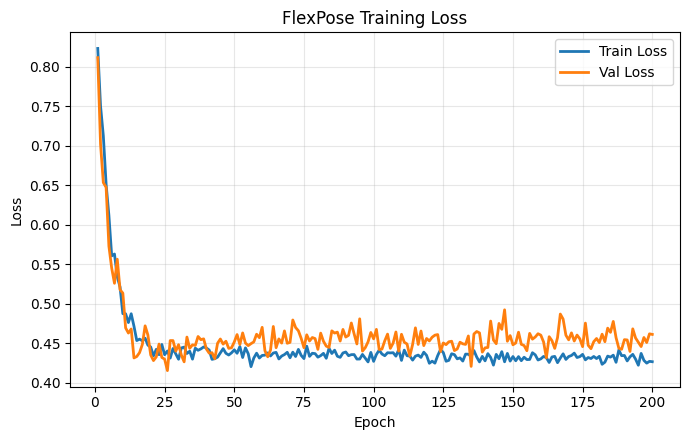

In [11]:
plot_loss_curves(train_loss_history, val_loss_history, title="FlexPose Training Loss")

## 总结

- 技术路线：FlexPose 的蛋白 / 配体联合坐标修正路线。
- 教学骨架：`nn.Linear() + nn.ReLU()`。
- 主指标：`RMSD < 2A`。